In [64]:
from pathlib import Path
import seaborn as sns
from scipy.stats import linregress
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats 
import numpy as np

import modsnow_drought as msd

In [24]:
def infer_snow_bands(snow_df: pd.DataFrame, use_16d: bool = True) -> list[str]:
    """
    Infer snow band columns from snow_df.
    If use_16d=True -> picks col_<n>_16d
    else -> picks col_<n>
    Returns numerically sorted list.
    """
    if use_16d:
        pattern = re.compile(r"^col_(\d+)_16d$")
    else:
        pattern = re.compile(r"^col_(\d+)$")

    bands = []
    for c in snow_df.columns:
        m = pattern.match(c)
        if m:
            bands.append((int(m.group(1)), c))

    # sort by the integer index
    bands.sort(key=lambda x: x[0])
    return [c for _, c in bands]


In [25]:
def compute_r2_grid(
    snow_df: pd.DataFrame,
    ndvi_df: pd.DataFrame,
    sca_range: tuple[int, int] = (129, 177),
    ndvi_range: tuple[int, int] = (209, 293),
    min_n: int = 5,
    use_16d: bool = True,
) -> pd.DataFrame:
    """
    Computes r² for all combinations of (SCA_DOY, NDVI_DOY) in the provided windows,
    across all inferred elevation-band columns in snow_df.

    Returns long table with: sca_doy, ndvi_doy, band, r2, n
    """
    # --- infer bands dynamically ---
    snow_bands = infer_snow_bands(snow_df, use_16d=use_16d)
    if not snow_bands:
        raise ValueError(
            "No snow band columns found. Expected columns like "
            "'col_1_16d'...'col_n_16d' (or 'col_1'...'col_n' if use_16d=False)."
        )

    # --- minimal sanity ---
    for req in ['Year', 'DOY']:
        if req not in snow_df.columns:
            raise ValueError(f"snow_df must contain '{req}'")
    for req in ['Year', 'DOY', 'NDVI']:
        if req not in ndvi_df.columns:
            raise ValueError(f"ndvi_df must contain '{req}'")

    records = []

    # optional: pre-slice NDVI once for speed
    ndvi_win = ndvi_df[
        ndvi_df['DOY'].between(ndvi_range[0], ndvi_range[1])
    ][['Year', 'DOY', 'NDVI']].dropna()

    for sca_doy in range(sca_range[0], sca_range[1] + 1):
        snow_doy = snow_df[snow_df['DOY'] == sca_doy]
        if snow_doy.empty:
            continue

        for ndvi_doy in range(ndvi_range[0], ndvi_range[1] + 1):
            ndvi_doy_df = ndvi_win[ndvi_win['DOY'] == ndvi_doy]
            if ndvi_doy_df.empty:
                continue

            # merge base once per DOY pair (then swap band columns)
            base = snow_doy[['Year'] + snow_bands].merge(
                ndvi_doy_df[['Year', 'NDVI']], on='Year', how='inner'
            )

            # evaluate each band
            for band in snow_bands:
                tmp = base[['Year', band, 'NDVI']].dropna()
                if len(tmp) < min_n:
                    continue

                r = linregress(tmp[band], tmp['NDVI']).rvalue
                records.append({
                    'sca_doy': sca_doy,
                    'ndvi_doy': ndvi_doy,
                    'band': band,
                    'r2': r ** 2,
                    'n': len(tmp)
                })

    return pd.DataFrame(records)

In [29]:
def parse_snow_filename(path: Path):
    stem = path.stem

    # catchment = everything before "_elevation_bands"
    catchment = stem.split('_elevation_bands')[0]

    # step = "500m" / "1000m" if present
    m = re.search(r'_(\d+)m', stem)
    step = f"{m.group(1)}m" if m else 'unknown'

    return catchment, step

dfs = []

In [26]:
snow_dir = Path('/Users/tillweiss/Desktop/MODSNOW/data/snow_altitude')
out_dir  = Path('/Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated')

out_dir.mkdir(parents=True, exist_ok=True)

In [42]:
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/pixel_filtered/NDVI_mean_wedge.csv'

ndvi = pd.read_csv(ndvi_path)
ndvi['Date'] = pd.to_datetime(ndvi['time'])

In [34]:
snow_dir

PosixPath('/Users/tillweiss/Desktop/MODSNOW/data/snow_altitude')

In [36]:
snow_dir = Path('/Users/tillweiss/Desktop/MODSNOW/data/snow_altitude')
out_dir  = Path('/Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated')
out_dir.mkdir(parents=True, exist_ok=True)

# NDVI once
ndvi_path = '/Users/tillweiss/Desktop/MODSNOW/data/pixel_filtered/NDVI_mean_wedge.csv'
ndvi = pd.read_csv(ndvi_path)
ndvi['Date'] = pd.to_datetime(ndvi['time'])

def parse_snow_filename(p: Path):
    stem = p.stem
    catchment = stem.split('_elevation_bands')[0]
    m = re.search(r'_(\d+)m', stem)
    step = f"{m.group(1)}m" if m else "unknown"
    return catchment, step

dfs = []

for snow_path in snow_dir.glob('*.txt'):
    catchment, step = parse_snow_filename(snow_path)

    out_csv = out_dir / f"{snow_path.stem}_agg.csv"

    df = msd.process_snow(
        snow_path=str(snow_path),
        ndvi=ndvi,
        out_csv=str(out_csv),
        window_days=16
    )

    df['catchment'] = catchment
    df['elevation_step'] = step
    df['source_file'] = snow_path.name  # super helpful later

    # overwrite the per-file output including metadata
    df.to_csv(out_csv, index=False)

    dfs.append(df)

master = pd.concat(dfs, ignore_index=True)
master_path = out_dir / "snow_aggregated_master.csv"
master.to_csv(master_path, index=False)

print("Saved master:", master_path)

/Users/tillweiss/Desktop/MODSNOW/code/modsnow_drought.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  snow = pd.read_csv(snow_path, delim_whitespace=True)
/Users/tillweiss/Desktop/MODSNOW/code/modsnow_drought.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  snow = pd.read_csv(snow_path, delim_whitespace=True)
/Users/tillweiss/Desktop/MODSNOW/code/modsnow_drought.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  snow = pd.read_csv(snow_path, delim_whitespace=True)
/Users/tillweiss/Desktop/MODSNOW/code/modsnow_drought.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  snow = pd.read_csv(sn

Saved master: /Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated/snow_aggregated_master.csv


In [ ]:
ndvi_sca = ndvi.join(master.set_index('Date'), on='Date', how='inner')


In [44]:
sca_master

,Date,Year,Day,Snow_Mean,col_1,col_2,col_3,col_4,col_1_16d,col_2_16d,...,col_13,col_5_16d,col_6_16d,col_7_16d,col_8_16d,col_9_16d,col_10_16d,col_11_16d,col_12_16d,col_13_16d
0,2000-02-18,2000,NaN,NaN,NaN,NaN,NaN,NaN,82.562857,100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-03-05,2000,65.0,18.96,92.46,100.00,100.00,100.00,72.734375,99.865000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-03-21,2000,81.0,0.16,48.00,99.24,100.00,100.00,31.900000,97.211875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-04-06,2000,97.0,0.00,20.32,93.69,99.96,100.00,6.623125,75.553125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-04-22,2000,113.0,0.00,0.16,33.23,86.87,100.00,0.448750,36.267500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3523,2025-06-26,2025,177.0,0.00,0.00,0.00,0.06,1.75,0.037500,0.030000,...,NaN,14.628750,52.840625,88.702500,95.833125,NaN,NaN,NaN,NaN,NaN
3524,2025-07-12,2025,NaN,NaN,NaN,NaN,NaN,NaN,0.039333,0.079333,...,NaN,5.768667,27.416000,57.178000,62.221333,NaN,NaN,NaN,NaN,NaN
3525,2025-07-28,2025,209.0,0.00,0.00,0.00,0.03,0.11,0.000000,0.000000,...,NaN,6.228000,34.706667,85.384000,100.000000,NaN,NaN,NaN,NaN,NaN
3526,2025-08-13,2025,225.0,0.00,0.00,0.00,0.00,0.11,0.000000,0.002500,...,NaN,4.625000,25.713125,66.225625,91.666875,NaN,NaN,NaN,NaN,NaN


In [45]:
import pandas as pd

# --- load snow master ---
snow_master = pd.read_csv(
    '/Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated/snow_aggregated_master.csv'
)

# IMPORTANT: parse Date so it's datetime, not object/string
snow_master['Date'] = pd.to_datetime(snow_master['Date'])

# --- load NDVI ---
ndvi = pd.read_csv('/Users/tillweiss/Desktop/MODSNOW/data/pixel_filtered/NDVI_mean_wedge.csv')

# build Date column (adjust 'time' if your column name differs)
ndvi['Date'] = pd.to_datetime(ndvi['time'])

# pick the NDVI column you actually want:
# if your NDVI column is already called NDVI, keep it; otherwise rename
# e.g. ndvi = ndvi.rename(columns={'Mean': 'NDVI'})
ndvi = ndvi[['Date', 'NDVI']].dropna()

# if NDVI has multiple rows per Date, collapse to one value per Date
ndvi = ndvi.groupby('Date', as_index=False)['NDVI'].mean()

# --- merge ---
master = snow_master.merge(ndvi, on='Date', how='left')

out_path = '/Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated/snow_master_with_ndvi.csv'
master.to_csv(out_path, index=False)

print("Saved:", out_path)


Saved: /Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated/snow_master_with_ndvi.csv


In [47]:
sca_master = pd.read_csv(
    '/Users/tillweiss/Desktop/MODSNOW/data/snow_aggregated/snow_master_with_ndvi.csv'
)
    
# identify snow bands dynamically
snow_bands = sorted(
    [c for c in master.columns if re.match(r'^col_\d+_16d$', c)],
    key=lambda x: int(x.split('_')[1])
)

snow_bands

['col_1_16d',
 'col_2_16d',
 'col_3_16d',
 'col_4_16d',
 'col_5_16d',
 'col_6_16d',
 'col_7_16d',
 'col_8_16d',
 'col_9_16d',
 'col_10_16d',
 'col_11_16d',
 'col_12_16d',
 'col_13_16d']

In [127]:
from scipy.stats import linregress

records = []

for sca_doy in range(129, 194):
    snow_slice = master[master['DOY'] == sca_doy]

    if snow_slice.empty:
        continue

    for ndvi_doy in range(209, 274):
        ndvi_slice = master[master['DOY'] == ndvi_doy]

        if ndvi_slice.empty:
            continue

        for band in snow_bands:
            tmp = (
                snow_slice[['Year', band, 'catchment', 'elevation_step']]
                .merge(
                    ndvi_slice[['Year', 'NDVI']],
                    on='Year',
                    how='inner'
                )
                .dropna()
            )

            if len(tmp) < 5:
                continue

            r = linregress(tmp[band], tmp['NDVI']).rvalue

            records.append({
                'sca_doy': sca_doy,
                'ndvi_doy': ndvi_doy,
                'catchment': tmp['catchment'].iloc[0],
                'elevation_step': tmp['elevation_step'].iloc[0],
                'band': band,
                'r2': r**2,
                'n': len(tmp)
            })


In [128]:
r2_all = pd.DataFrame(records)
r2_all.to_csv(
    '/Users/tillweiss/Desktop/MODSNOW/data/snow_nadvi_r2.csv', index=False)

In [129]:
r2_all

,sca_doy,ndvi_doy,catchment,elevation_step,band,r2,n
0,129,209,kafirnigan_tartki,1000m,col_1_16d,0.007461,936
1,129,209,kafirnigan_tartki,1000m,col_2_16d,0.009203,936
2,129,209,kafirnigan_tartki,1000m,col_3_16d,0.003442,936
3,129,209,kafirnigan_tartki,1000m,col_4_16d,0.003924,936
4,129,209,amudarya_kerky,0500m,col_5_16d,0.015601,624
...,...,...,...,...,...,...,...
320,193,273,amudarya_kerky,0500m,col_9_16d,0.044416,150
321,193,273,amudarya_kerky,0500m,col_10_16d,0.066895,150
322,193,273,amudarya_kerky,0500m,col_11_16d,0.075490,150
323,193,273,amudarya_kerky,0500m,col_12_16d,0.000122,150


In [130]:
best_per_pair = (
    r2_all
    .sort_values('r2', ascending=False)
    .groupby(['sca_doy', 'ndvi_doy'], as_index=False)
    .first()
)
best_per_pair

,sca_doy,ndvi_doy,catchment,elevation_step,band,r2,n
0,129,209,amudarya_kerky,0500m,col_10_16d,0.244299,156
1,129,225,amudarya_kerky,0500m,col_9_16d,0.341250,156
2,129,241,amudarya_kerky,0500m,col_10_16d,0.364452,156
3,129,257,amudarya_kerky,0500m,col_9_16d,0.281554,150
4,129,273,amudarya_kerky,0500m,col_9_16d,0.281595,150
5,145,209,amudarya_kerky,0500m,col_10_16d,0.307873,156
6,145,225,amudarya_kerky,0500m,col_10_16d,0.432400,156
7,145,241,amudarya_kerky,0500m,col_10_16d,0.425272,156
8,145,257,amudarya_kerky,0500m,col_10_16d,0.396001,150
9,145,273,amudarya_kerky,0500m,col_10_16d,0.383742,150


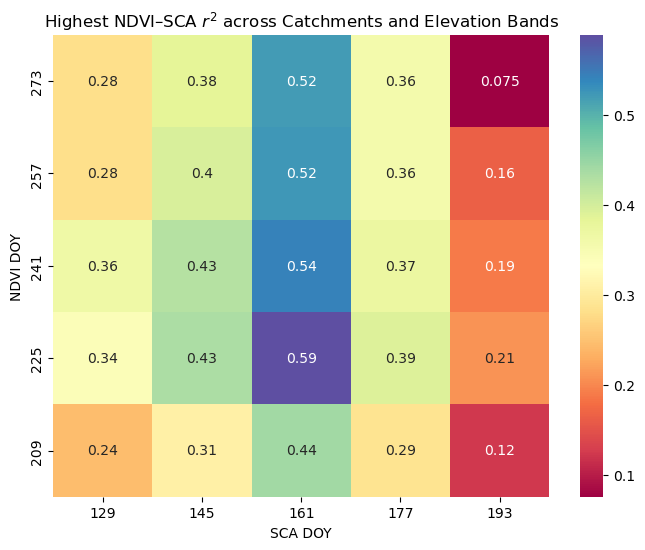

In [131]:
final_r2_matrix = best_per_pair.pivot(
    index='ndvi_doy',
    columns='sca_doy',
    values='r2'
)

plt.figure(figsize=(8,6))
sns.heatmap(final_r2_matrix, annot=True, cmap='Spectral').invert_yaxis()

plt.xlabel('SCA DOY')
plt.ylabel('NDVI DOY')
plt.title('Highest NDVI–SCA $r^2$ across Catchments and Elevation Bands')
plt.show()

In [132]:
band_matrix = best_per_pair.pivot(
    index='ndvi_doy',
    columns='sca_doy',
    values='band'
)
band_matrix

sca_doy,129,145,161,177,193
ndvi_doy,,,,,
209,col_10_16d,col_10_16d,col_10_16d,col_10_16d,col_10_16d
225,col_9_16d,col_10_16d,col_10_16d,col_10_16d,col_10_16d
241,col_10_16d,col_10_16d,col_10_16d,col_10_16d,col_10_16d
257,col_9_16d,col_10_16d,col_10_16d,col_13_16d,col_11_16d
273,col_9_16d,col_10_16d,col_13_16d,col_13_16d,col_11_16d


In [133]:
n_matrix = best_per_pair.pivot(
    index='ndvi_doy',
    columns='sca_doy',
    values='n'
)
n_matrix

sca_doy,129,145,161,177,193
ndvi_doy,,,,,
209,156,156,156,156,156
225,156,156,156,156,156
241,156,156,156,156,156
257,150,150,150,150,150
273,150,150,150,150,150


In [134]:
catchment_matrix = best_per_pair.pivot(
    index='ndvi_doy',
    columns='sca_doy',
    values='catchment'
)
catchment_matrix

sca_doy,129,145,161,177,193
ndvi_doy,,,,,
209,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky
225,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky
241,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky
257,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky
273,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky,amudarya_kerky


In [135]:
elevation_matrix = best_per_pair.pivot(
    index='ndvi_doy',
    columns='sca_doy',
    values='elevation_step'
)
elevation_matrix

sca_doy,129,145,161,177,193
ndvi_doy,,,,,
209,0500m,0500m,0500m,0500m,0500m
225,0500m,0500m,0500m,0500m,0500m
241,0500m,0500m,0500m,0500m,0500m
257,0500m,0500m,0500m,0500m,0500m
273,0500m,0500m,0500m,0500m,0500m


In [136]:
best_per_pair.sort_values('r2', ascending=False).head(10)

,sca_doy,ndvi_doy,catchment,elevation_step,band,r2,n
11,161,225,amudarya_kerky,0500m,col_10_16d,0.588720,156
12,161,241,amudarya_kerky,0500m,col_10_16d,0.542178,156
13,161,257,amudarya_kerky,0500m,col_10_16d,0.523154,150
14,161,273,amudarya_kerky,0500m,col_13_16d,0.519516,150
10,161,209,amudarya_kerky,0500m,col_10_16d,0.440481,156
6,145,225,amudarya_kerky,0500m,col_10_16d,0.432400,156
7,145,241,amudarya_kerky,0500m,col_10_16d,0.425272,156
8,145,257,amudarya_kerky,0500m,col_10_16d,0.396001,150
16,177,225,amudarya_kerky,0500m,col_10_16d,0.390947,156
9,145,273,amudarya_kerky,0500m,col_10_16d,0.383742,150


In [139]:
def compute_regressions_from_best_pairs(master, best_per_pair, min_n=5):
    rows = []

    # index for faster filtering
    master = master.copy()
    master['Year'] = master['Year'].astype(int)
    master['DOY'] = master['DOY'].astype(int)

    for _, row in best_per_pair.iterrows():
        sca_doy  = int(row['sca_doy'])
        ndvi_doy = int(row['ndvi_doy'])
        band     = row['band']

        snow_slice = master[master['DOY'] == sca_doy][['Year', band]].dropna()
        ndvi_slice = master[master['DOY'] == ndvi_doy][['Year', 'NDVI']].dropna()

        aligned = snow_slice.merge(ndvi_slice, on='Year', how='inner').dropna()
        if len(aligned) < min_n:
            continue

        x = aligned[band].to_numpy()
        y = aligned['NDVI'].to_numpy()

        res = stats.linregress(x, y)

        y_pred = res.intercept + res.slope * x
        rmse = float(np.sqrt(np.mean((y - y_pred) ** 2)))

        rows.append({
            'sca_doy': sca_doy,
            'ndvi_doy': ndvi_doy,
            'band': band,
            'n': len(aligned),
            'slope': res.slope,
            'intercept': res.intercept,
            'r': res.rvalue,
            'r2': res.rvalue**2,
            'p': res.pvalue,
            'rmse': rmse,
        })

    return pd.DataFrame(rows)

def plot_regression_pages(master, reg_table, ncols=6, nrows=6, min_n=5, share_axes=True):
    per_page = ncols * nrows
    n_pages = int(np.ceil(len(reg_table) / per_page))

    # for consistent axes (optional but helpful)
    if share_axes:
        x_min = np.inf
        x_max = -np.inf
        y_min = np.inf
        y_max = -np.inf

        # compute global limits from a subsample (or full if you dare)
        for _, row in reg_table.iterrows():
            sca_doy  = int(row['sca_doy'])
            ndvi_doy = int(row['ndvi_doy'])
            band     = row['band']

            snow_slice = master[master['DOY'] == sca_doy][['Year', band]].dropna()
            ndvi_slice = master[master['DOY'] == ndvi_doy][['Year', 'NDVI']].dropna()
            aligned = snow_slice.merge(ndvi_slice, on='Year', how='inner').dropna()

            if len(aligned) < min_n:
                continue

            x = aligned[band].to_numpy()
            y = aligned['NDVI'].to_numpy()

            x_min = min(x_min, np.nanmin(x))
            x_max = max(x_max, np.nanmax(x))
            y_min = min(y_min, np.nanmin(y))
            y_max = max(y_max, np.nanmax(y))

    for page in range(n_pages):
        chunk = reg_table.iloc[page*per_page : (page+1)*per_page]

        fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*3.0), dpi = 300)
        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, chunk.iterrows()):
            sca_doy  = int(row['sca_doy'])
            ndvi_doy = int(row['ndvi_doy'])
            band     = row['band']

            snow_slice = master[master['DOY'] == sca_doy][['Year', band]].dropna()
            ndvi_slice = master[master['DOY'] == ndvi_doy][['Year', 'NDVI']].dropna()
            aligned = snow_slice.merge(ndvi_slice, on='Year', how='inner').dropna()

            x = aligned[band].to_numpy()
            y = aligned['NDVI'].to_numpy()

            # fit line from stored params
            slope = row['slope']
            intercept = row['intercept']

            x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            y_fit = intercept + slope * x_fit

            ax.scatter(x, y, alpha=0.7, s=10)
            ax.plot(x_fit, y_fit, linewidth=2, color='red')

            ax.text(
                0.96, 0.04,
                f'n = {int(row["n"])}\n'
                f'r = {row["r"]:.2f}\n'
                f'$r^2$ = {row["r2"]:.3f}\n'
                f'p = {row["p"]:.2e}\n'
                f'RMSE = {row["rmse"]:.3f}'
                f'NDVI = {slope:.3f} × SCA + {intercept:.3f}\n',
                transform=ax.transAxes,
                va='bottom', ha='right',
                fontsize=8,
                bbox=dict(
                    boxstyle='round,pad=0.25',
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.65
                )
            )

            ax.set_title(
                f'{band} | SCA DOY {sca_doy} → NDVI DOY {ndvi_doy}',
                fontsize=9
            )
            ax.grid(True)

        # turn off unused axes
        for ax in axes[len(chunk):]:
            ax.axis('off')

        fig.suptitle(f'Regressions (page {page+1}/{n_pages})', y=1.01, fontsize=14)
        fig.tight_layout()
        plt.show()


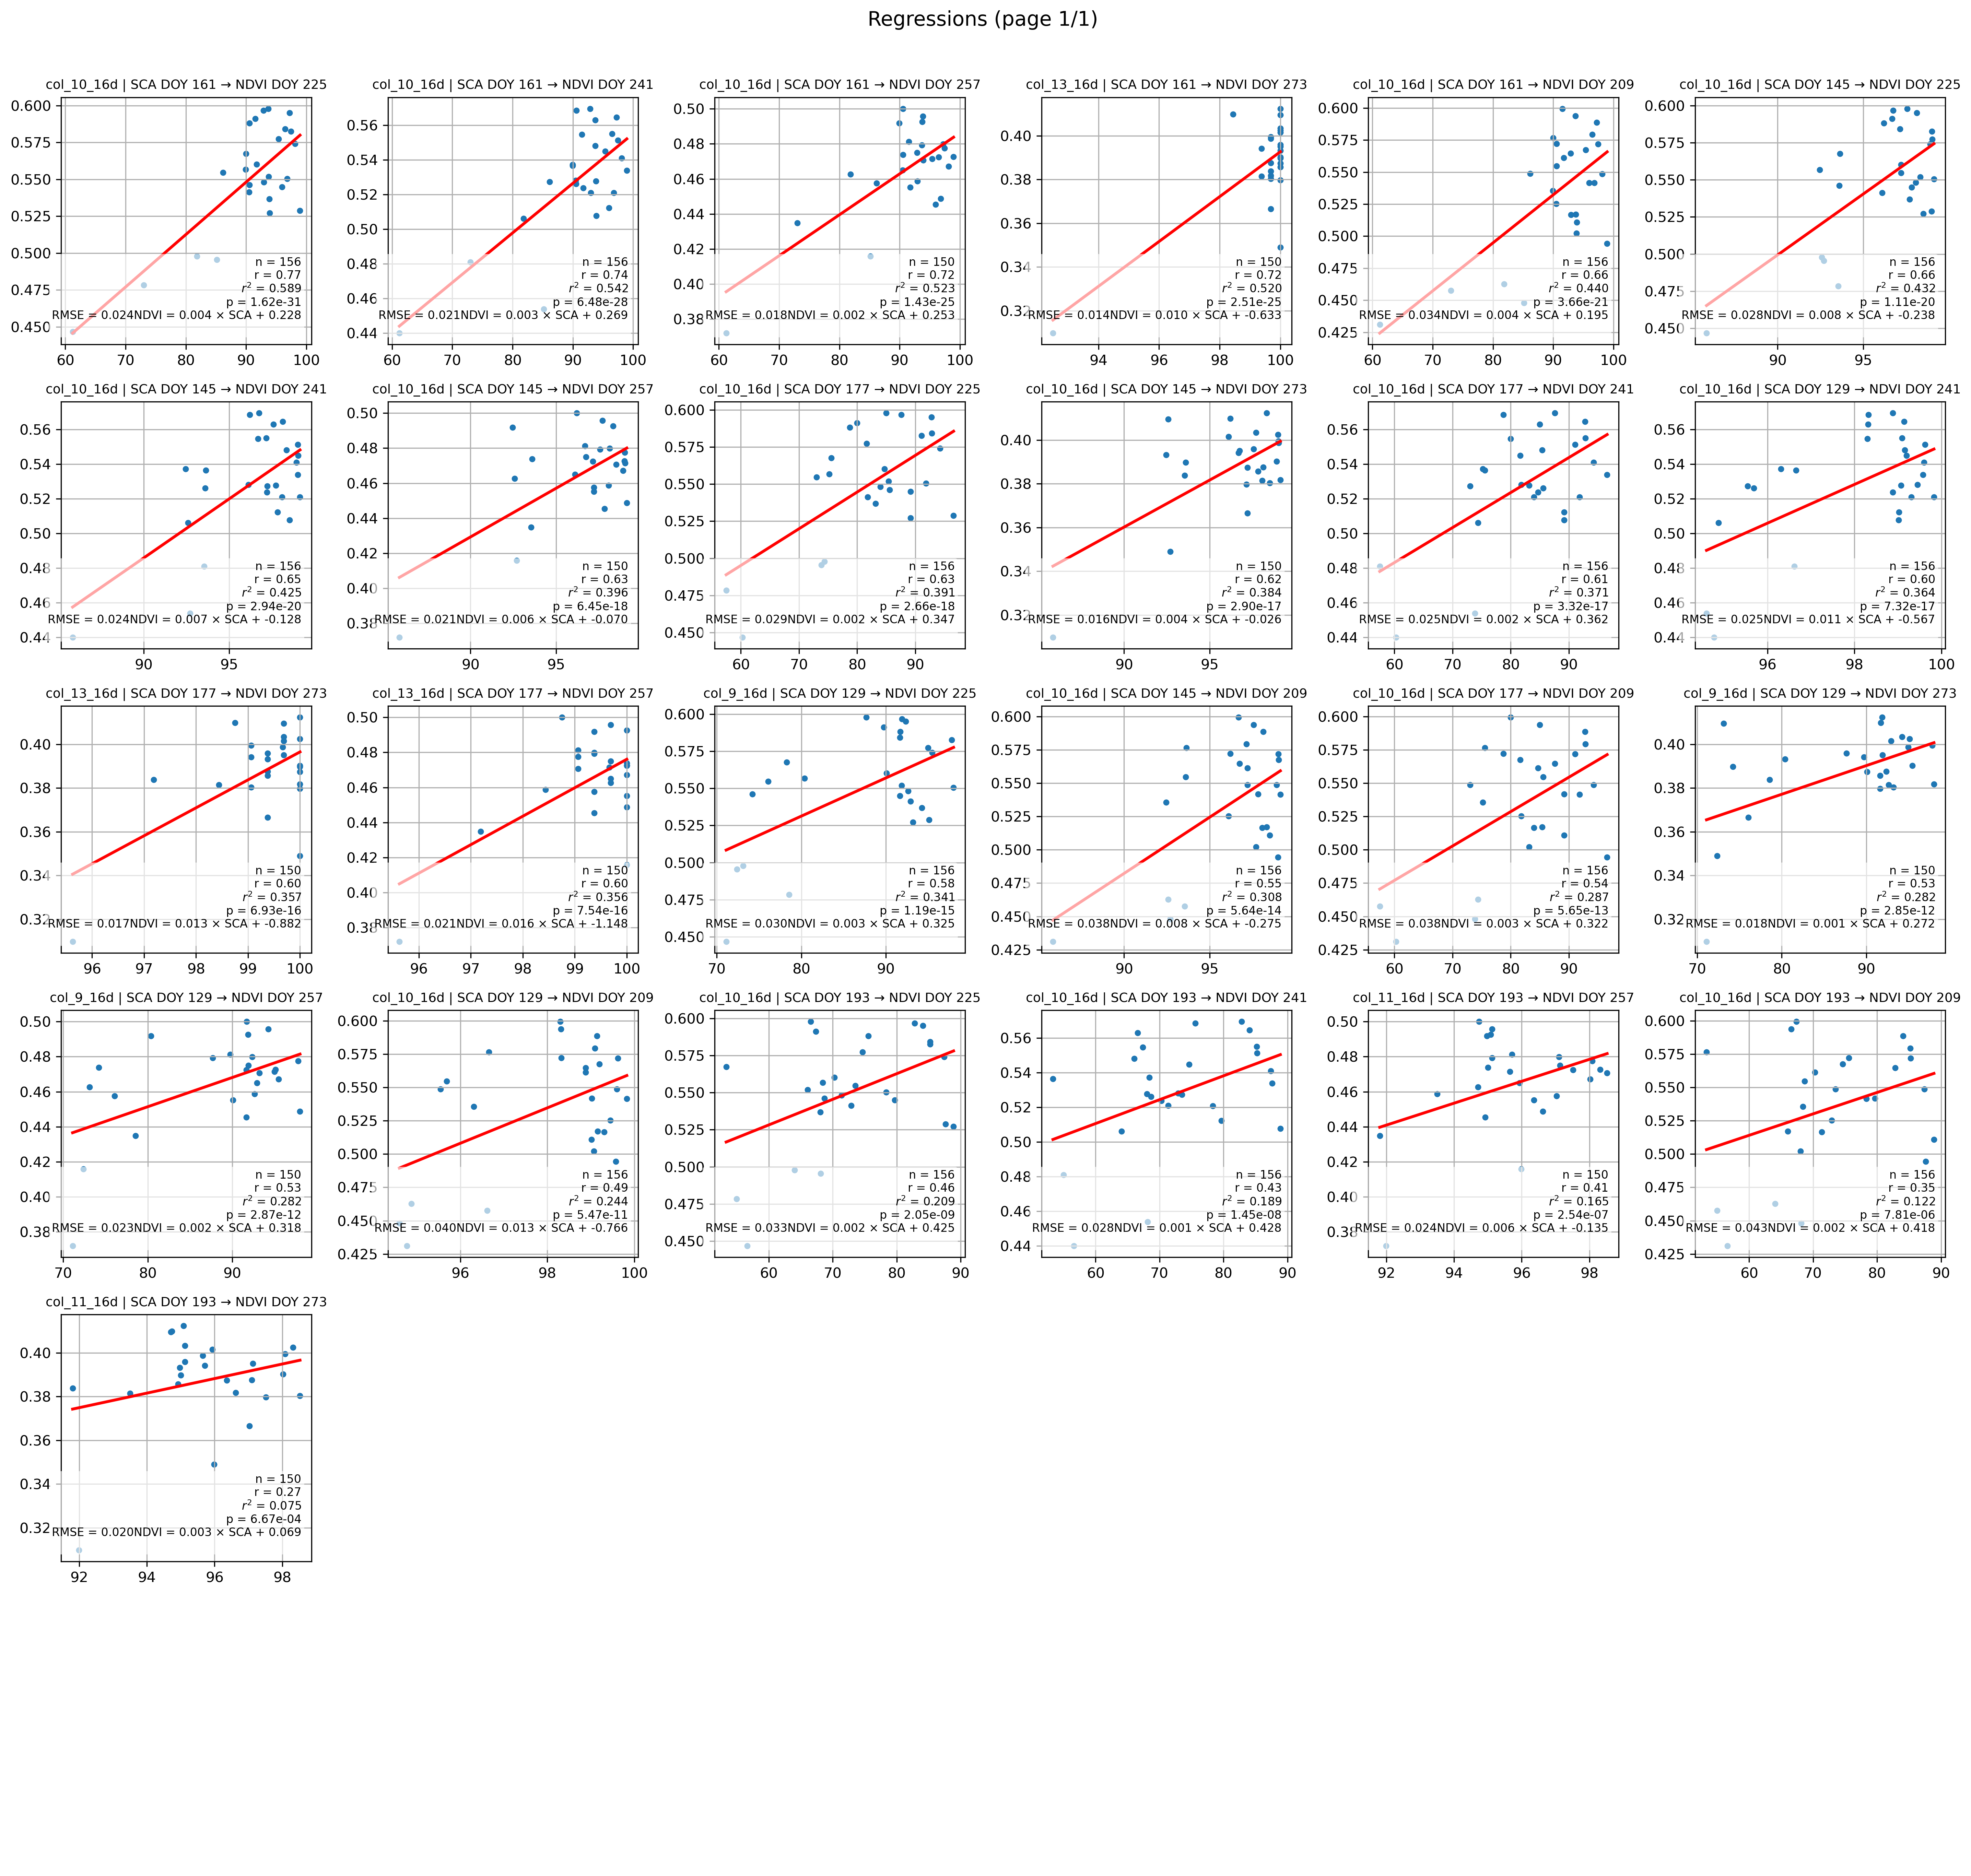

In [140]:
reg_table = compute_regressions_from_best_pairs(master, best_per_pair, min_n=5)

# optional: sort so you see strongest first
reg_table = reg_table.sort_values('r2', ascending=False).reset_index(drop=True)

plot_regression_pages(master, reg_table, ncols=6, nrows=6, share_axes=True)
